In [1]:
import torch
from torchvision.datasets import CIFAR100
import torchvision.models as models

In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [6]:
from dataset_pipeline import DatasetPipeline
from dataloader_factory import DataLoaderFactory

from utils import (
    tune_optimizers_with_optuna,
    print_hyperparams_table
)

In [9]:
batch_size = 32
num_epochs = 5
learning_rate = 1e-3
seed = 42
num_classes = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
pipeline = DatasetPipeline(
    seed=seed
)
train_ds, val_ds, test_ds = pipeline.prepare_vision(CIFAR100)
loader_factory = DataLoaderFactory(task_type="vision", batch_size=batch_size)
train_loader, val_loader, test_loader = loader_factory.create_loaders(
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds
)

100%|██████████| 169M/169M [00:48<00:00, 3.48MB/s] 


## Optuna

In [11]:
optimizers = ["Adam"]# , "SGD", "RMSprop"]
best_params = tune_optimizers_with_optuna(optimizers, 
                                          n_trials=3,
                                          train_dataset=train_ds,
                                          val_dataset=val_ds,
                                          num_classes=num_classes,
                                          task_type="vision",
                                          model_fn=lambda num_classes: models.resnet18(
                                              num_classes=num_classes
                                          ))

print("\n📋 Podsumowanie:")
for opt, params in best_params.items():
    print(f"{opt}: {params}")

[I 2025-05-22 00:48:04,406] A new study created in memory with name: no-name-d0398b64-1844-4a10-80e6-c15f118bdd9b


Hyperparameter tuning for: Adam


[I 2025-05-22 00:58:26,417] Trial 0 finished with value: 0.144 and parameters: {'learning_rate': 0.008354658227732958, 'batch_size': 16, 'num_epochs': 2}. Best is trial 0 with value: 0.144.
[W 2025-05-22 00:58:50,926] Trial 1 failed with parameters: {'learning_rate': 0.06343669065279207, 'batch_size': 8, 'num_epochs': 2} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\kacpe\Code\Uni\25L\ZZSN\ZZSN-optimizers\.venv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "c:\Users\kacpe\Code\Uni\25L\ZZSN\ZZSN-optimizers\utils.py", line 176, in wrapped_objective
    return objective(trial,
          ^^^^^^^^^^^^^^^^
  File "c:\Users\kacpe\Code\Uni\25L\ZZSN\ZZSN-optimizers\utils.py", line 93, in objective
    outputs = model(inputs)
              ^^^^^^^^^^^^^
  File "c:\Users\kacpe\Code\Uni\25L\ZZSN\ZZSN-optimizers\.venv\Lib\site-packages\torch\n

KeyboardInterrupt: 

In [6]:
print_hyperparams_table(best_params)

╒═════════════╤═════════════════╤═════════════════════════════════════════════════════════════════════════════╕
│ Optimizer   │   Best Accuracy │ Best Hyperparameters                                                        │
╞═════════════╪═════════════════╪═════════════════════════════════════════════════════════════════════════════╡
│ Adam        │          0.1651 │ {'learning_rate': 3.259776072331879e-05, 'batch_size': 16, 'num_epochs': 1} │
├─────────────┼─────────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ SGD         │          0.249  │ {'learning_rate': 0.004522993377803465, 'batch_size': 16, 'num_epochs': 2}  │
├─────────────┼─────────────────┼─────────────────────────────────────────────────────────────────────────────┤
│ RMSprop     │          0.2438 │ {'learning_rate': 0.0002782659709068034, 'batch_size': 32, 'num_epochs': 1} │
╘═════════════╧═════════════════╧═══════════════════════════════════════════════════════════════════════

## Training

In [7]:
from train_compare import compare_optimizers_with_metrics

In [8]:
import neptune

run = neptune.init_run(
    project="notatkipw/ZZSN",
    api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiIyMzQ0ZWY0Zi0wZmZhLTRjZGItODRlNS02YWE5NmY5Yjc3OWIifQ==",            # Replace with your Neptune API token
)

[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs-legacy.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/notatkipw/ZZSN/e/ZZSN-37


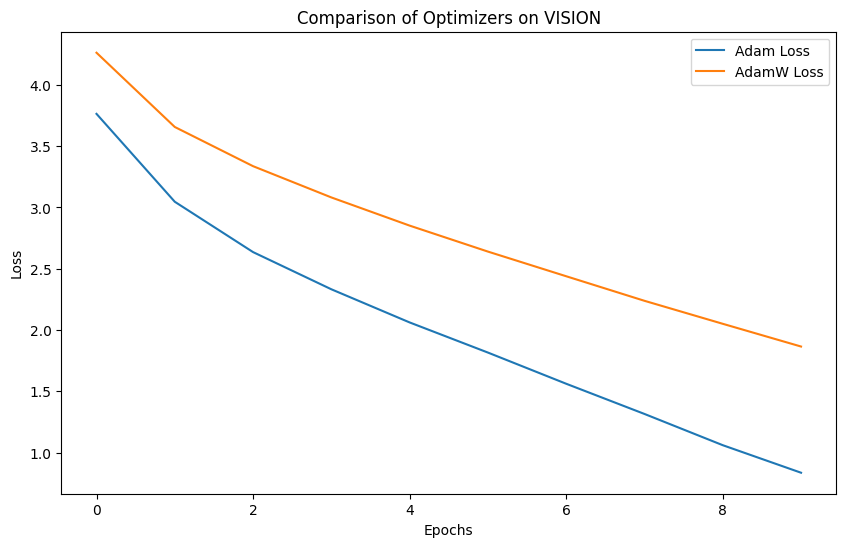

Optimizer: Adam
Accuracy: 0.4296
Precision: 0.4494
Recall: 0.4296
F1 Score: 0.4282
------------------------------
Optimizer: AdamW
Accuracy: 0.2685
Precision: 0.2674
Recall: 0.2685
F1 Score: 0.2650
------------------------------
[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 5 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 5 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/notatkipw/ZZSN/e/ZZSN-37/metadata


In [9]:
# optimizers = ["ADOPT", "SGD", "Adam", "AdamW", "RMSprop"]
optimizers = {
    "Adam": {"lr": 1e-3},
    "AdamW": {"lr": 2e-5, "weight_decay": 0.01}
}

compare_optimizers_with_metrics(
    optimizers=optimizers, 
    run=run,
    model_fn=lambda num_classes: models.resnet18(num_classes=num_classes),
    train_loader=train_loader,
    test_loader=test_loader,
    task_type="vision",
    num_classes=num_classes,
    epochs=10,
    device=device
)

run.stop()